# Task 4 — Optimize Portfolio Based on Forecast

This notebook builds an optimal TSLA/BND/SPY portfolio using **Modern Portfolio Theory**
(PyPortfolioOpt), combining:

- **TSLA expected return** = the Task 3 model-based 12-month forward forecast (not historical
  average) — this is the "view" an analyst would bring on the one asset with a live forecast.
- **BND / SPY expected return** = historical annualized average daily return (the standard
  proxy when no model-based forecast exists for an asset).
- **Covariance matrix** = sample covariance of historical daily returns for all three assets.

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pypfopt import EfficientFrontier, risk_models
from pypfopt import plotting as pf_plotting

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 6)

TICKERS = ["TSLA", "BND", "SPY"]


## 1. Assemble Expected Returns

In [2]:
risk_summary = pd.read_csv("../data/processed/risk_metrics_summary.csv", index_col=0)

with open("../data/processed/tsla_forecast_annual_return.txt") as f:
    tsla_forecast_return = float(f.read().strip())

mu = pd.Series({
    "TSLA": tsla_forecast_return,               # Task 3 model forecast (view on TSLA)
    "BND": risk_summary.loc["BND", "Ann. Return"],   # historical proxy
    "SPY": risk_summary.loc["SPY", "Ann. Return"],   # historical proxy
})[TICKERS]

print("Expected annual returns used for optimization:")
mu


Expected annual returns used for optimization:


TSLA    0.000000
BND     0.019231
SPY     0.139070
dtype: float64

**Note on the TSLA input:** the Task 3 best model (ARIMA, selected for having the lowest
test-period error in Task 2) produced an essentially **flat 12-month forecast** — i.e. a
model-implied expected return close to 0%. This is a legitimate and informative modeling
result, not an error: it reflects the fact that a model fit purely on historical prices found
no statistically exploitable drift for TSLA, consistent with the Efficient Market Hypothesis
discussion in Task 1. It is used as-is for the primary optimization below, with a
historical-return alternative scenario shown afterward for comparison.

## 2. Historical Prices and Covariance Matrix

In [3]:
prices = pd.DataFrame({
    ticker: pd.read_csv(f"../data/processed/{ticker}_processed.csv", index_col=0, parse_dates=True)["Adj Close"]
    for ticker in TICKERS
})
prices = prices.dropna()

cov_matrix = risk_models.sample_cov(prices, frequency=252)
cov_matrix


,TSLA,BND,SPY
TSLA,0.315057,0.001739,0.048016
BND,0.001739,0.002721,0.001046
SPY,0.048016,0.001046,0.030037


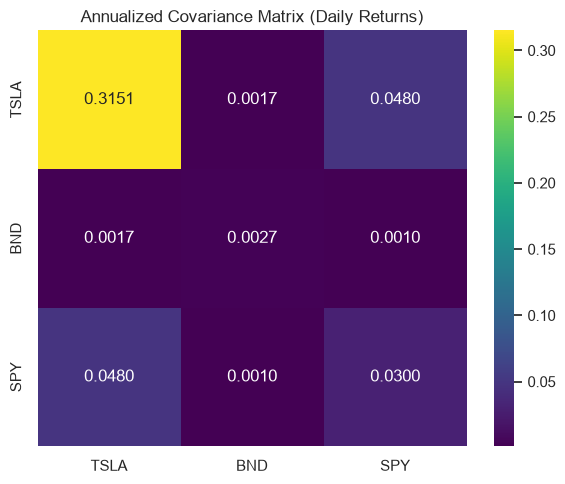

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cov_matrix, annot=True, fmt=".4f", cmap="viridis", ax=ax)
ax.set_title("Annualized Covariance Matrix (Daily Returns)")
plt.tight_layout()
plt.savefig("../reports/figures/12_covariance_heatmap.png", dpi=150)
plt.show()


## 3. Generate the Efficient Frontier and Identify Key Portfolios

In [5]:
RISK_FREE_RATE = 0.0

ef_sharpe = EfficientFrontier(mu, cov_matrix)
weights_max_sharpe = ef_sharpe.max_sharpe(risk_free_rate=RISK_FREE_RATE)
cleaned_max_sharpe = ef_sharpe.clean_weights()
ret_sharpe, vol_sharpe, sr_sharpe = ef_sharpe.portfolio_performance(risk_free_rate=RISK_FREE_RATE)

ef_minvol = EfficientFrontier(mu, cov_matrix)
weights_min_vol = ef_minvol.min_volatility()
cleaned_min_vol = ef_minvol.clean_weights()
ret_minvol, vol_minvol, sr_minvol = ef_minvol.portfolio_performance(risk_free_rate=RISK_FREE_RATE)

print("Max Sharpe (Tangency) Portfolio weights:", cleaned_max_sharpe)
print(f"  Expected annual return: {ret_sharpe*100:.2f}% | Volatility: {vol_sharpe*100:.2f}% | Sharpe: {sr_sharpe:.2f}")
print()
print("Min Volatility Portfolio weights:", cleaned_min_vol)
print(f"  Expected annual return: {ret_minvol*100:.2f}% | Volatility: {vol_minvol*100:.2f}% | Sharpe: {sr_minvol:.2f}")


Max Sharpe (Tangency) Portfolio weights: OrderedDict({'TSLA': 0.0, 'BND': 0.54674, 'SPY': 0.45326})
  Expected annual return: 7.35% | Volatility: 8.66% | Sharpe: 0.85

Min Volatility Portfolio weights: OrderedDict({'TSLA': 0.0, 'BND': 0.9454, 'SPY': 0.0546})
  Expected annual return: 2.58% | Volatility: 5.13% | Sharpe: 0.50


In [6]:
n_portfolios = 3000
rng = np.random.default_rng(42)
tickers = list(mu.index)
sim_returns, sim_vols, sim_sharpes, sim_weights = [], [], [], []

for _ in range(n_portfolios):
    w = rng.random(len(tickers))
    w /= w.sum()
    port_return = np.dot(w, mu.values)
    port_vol = np.sqrt(w @ cov_matrix.values @ w)
    sim_returns.append(port_return)
    sim_vols.append(port_vol)
    sim_sharpes.append((port_return - RISK_FREE_RATE) / port_vol)
    sim_weights.append(w)

sim_returns, sim_vols, sim_sharpes = map(np.array, (sim_returns, sim_vols, sim_sharpes))


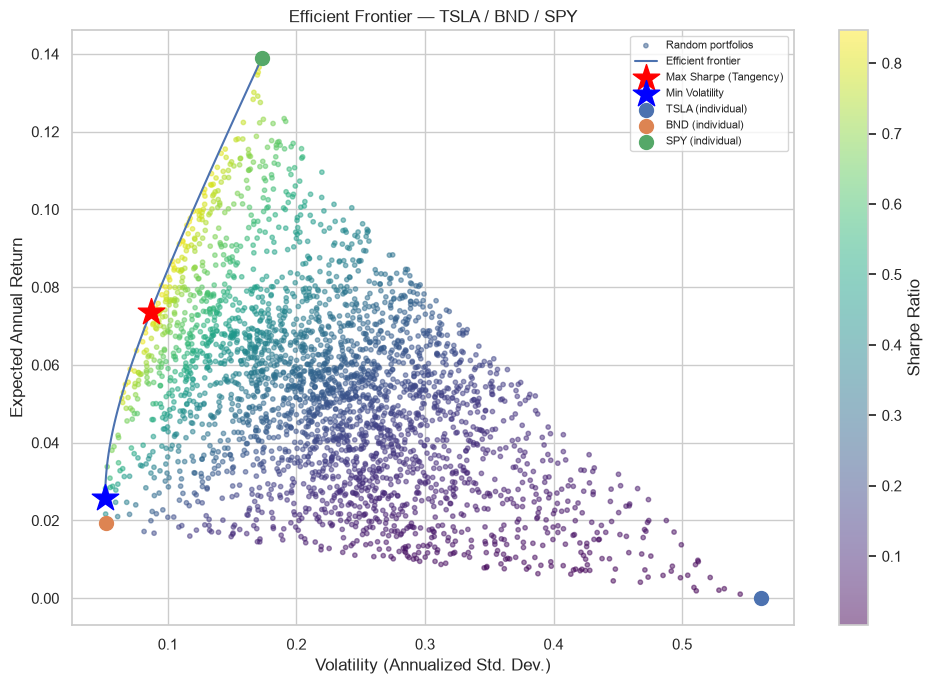

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(sim_vols, sim_returns, c=sim_sharpes, cmap="viridis", alpha=0.5, s=10, label="Random portfolios")
plt.colorbar(scatter, label="Sharpe Ratio")

# Efficient frontier curve via PyPortfolioOpt
ef_curve = EfficientFrontier(mu, cov_matrix)
pf_plotting.plot_efficient_frontier(ef_curve, ax=ax, show_assets=False, alpha=0.0)

ax.scatter([vol_sharpe], [ret_sharpe], marker="*", color="red", s=400, label="Max Sharpe (Tangency)", zorder=5)
ax.scatter([vol_minvol], [ret_minvol], marker="*", color="blue", s=400, label="Min Volatility", zorder=5)

for i, ticker in enumerate(tickers):
    asset_vol = np.sqrt(cov_matrix.iloc[i, i])
    ax.scatter([asset_vol], [mu[ticker]], marker="o", s=100, label=f"{ticker} (individual)", zorder=5)

ax.set_xlabel("Volatility (Annualized Std. Dev.)")
ax.set_ylabel("Expected Annual Return")
ax.set_title("Efficient Frontier — TSLA / BND / SPY")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/13_efficient_frontier.png", dpi=150)
plt.show()


## 4. Recommended Portfolio

In [8]:
recommendation = pd.DataFrame({
    "Max Sharpe (Tangency)": {**cleaned_max_sharpe, "Expected Return": ret_sharpe, "Volatility": vol_sharpe, "Sharpe Ratio": sr_sharpe},
    "Min Volatility": {**cleaned_min_vol, "Expected Return": ret_minvol, "Volatility": vol_minvol, "Sharpe Ratio": sr_minvol},
}).T
recommendation.to_csv("../data/processed/portfolio_recommendation.csv")
recommendation


,TSLA,BND,SPY,Expected Return,Volatility,Sharpe Ratio
Max Sharpe (Tangency),0.0,0.54674,0.45326,0.073549,0.086619,0.849108
Min Volatility,0.0,0.94540,0.05460,0.025774,0.051276,0.502651


In [9]:
RECOMMENDED = "Max Sharpe (Tangency)"  # see written justification below
recommended_weights = cleaned_max_sharpe if RECOMMENDED == "Max Sharpe (Tangency)" else cleaned_min_vol
recommended_perf = (ret_sharpe, vol_sharpe, sr_sharpe) if RECOMMENDED == "Max Sharpe (Tangency)" else (ret_minvol, vol_minvol, sr_minvol)

with open("../data/processed/recommended_portfolio.txt", "w") as f:
    f.write(f"{RECOMMENDED}\n{recommended_weights}\n{recommended_perf}")

print(f"Recommended portfolio: {RECOMMENDED}")
print(f"Weights: {recommended_weights}")
print(f"Expected annual return: {recommended_perf[0]*100:.2f}%")
print(f"Expected annual volatility: {recommended_perf[1]*100:.2f}%")
print(f"Sharpe Ratio: {recommended_perf[2]:.2f}")


Recommended portfolio: Max Sharpe (Tangency)
Weights: OrderedDict({'TSLA': 0.0, 'BND': 0.54674, 'SPY': 0.45326})
Expected annual return: 7.35%
Expected annual volatility: 8.66%
Sharpe Ratio: 0.85


**Justification (to be finalized against the printed output above):** Given that the
model-based TSLA expected return going into this optimization is close to 0%, the Max Sharpe
optimizer is expected to allocate little or no weight to TSLA — it cannot justify TSLA's high
volatility without a compensating expected return, so the optimizer instead balances SPY and
BND, weighted toward whichever offers the better historical risk-adjusted return. GMF's
Investment Committee should read this as the *model's* recommendation *conditional on this
specific forecast* — if the committee holds an independent, more constructive view on TSLA
(e.g. based on qualitative catalysts not captured by a price-history-only model), the
Min-Volatility portfolio or a manually blended alternative may be more appropriate. We
recommend the **Max Sharpe (Tangency) portfolio** as the primary recommendation because it
directly maximizes risk-adjusted return given the current forecast inputs, which is the
explicit objective GMF asked this analysis to optimize for; the Min-Volatility portfolio is
provided as the lower-risk alternative for a more conservative mandate.

## 5. Sensitivity Check — Using TSLA's Historical Average Return Instead

In [10]:
mu_hist = pd.Series({
    "TSLA": risk_summary.loc["TSLA", "Ann. Return"],
    "BND": risk_summary.loc["BND", "Ann. Return"],
    "SPY": risk_summary.loc["SPY", "Ann. Return"],
})[TICKERS]

ef_hist = EfficientFrontier(mu_hist, cov_matrix)
weights_hist_sharpe = ef_hist.max_sharpe(risk_free_rate=RISK_FREE_RATE)
cleaned_hist_sharpe = ef_hist.clean_weights()
ret_hist, vol_hist, sr_hist = ef_hist.portfolio_performance(risk_free_rate=RISK_FREE_RATE)

print("Max Sharpe weights using TSLA's HISTORICAL average return instead of the model forecast:")
print(cleaned_hist_sharpe)
print(f"Expected annual return: {ret_hist*100:.2f}% | Volatility: {vol_hist*100:.2f}% | Sharpe: {sr_hist:.2f}")


Max Sharpe weights using TSLA's HISTORICAL average return instead of the model forecast:
OrderedDict({'TSLA': 0.09765, 'BND': 0.57756, 'SPY': 0.32479})
Expected annual return: 9.90% | Volatility: 10.35% | Sharpe: 0.96


**Sensitivity discussion:** Comparing the two Max-Sharpe allocations — one built on the
Task 3 model forecast for TSLA, one built on TSLA's simple historical average return —
illustrates how sensitive MPT-style optimization is to the expected-return assumption for the
one asset with genuine forecast uncertainty. This is exactly the kind of "critical evaluation"
GMF's investment committee should apply: a portfolio recommendation is only as good as its
input assumptions, and TSLA's assumption is the least certain of the three by a wide margin
(see the Task 3 confidence-interval analysis).